In [23]:
import numpy as np
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

explore a Multi-Class Classification workflow using an Artificial Neural Network (ANN) implemented via Keras


Neural Network is a broad category of models inspired by the human brain. Common types include ANN for structured/tabular data, CNN for image data, RNN/LSTM for sequential data, and Transformers for modern NLP and generative AI applications.

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


Total Dataset Size: 70,000 grayscale images of handwritten digits (0 through 9)
Resolution per Image: 28 * 28 pixels
Total Input Features: 28 *28 = 784 unique pixel values per image
Data Split: 60,000 images for training (x_train) and 10,000 images for testing (x_test)
Target Labels (y_train / y_test): Integers representing categories from 0 to 9

[Input Layer: 28x28 Image]
         │
         ▼
 ┌───────────────┐
 │ Flatten Layer │ ──► Reshapes 2D Matrix into a 1D Vector (784 Nodes)
 └───────────────┘
         │
         ▼
 ┌───────────────┐
 │ Dense Layer 1 │ ──► 128 Hidden Nodes with ReLU Activation
 └───────────────┘
         │
         ▼
 ┌───────────────┐
 │ Output Layer  │ ──► 10 Nodes with Softmax Activation (one for each digit 0-9)
 └───────────────┘

In [4]:
X_train.shape

(60000, 28, 28)

In [6]:
X_test.shape

(10000, 28, 28)

In [7]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

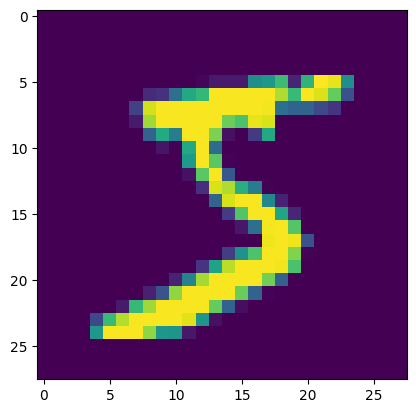

In [8]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [10]:
X_train[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         54, 227, 253, 252, 239, 233, 252,  57,   6,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  10,  60,
        224, 252, 253, 252, 202,  84, 252, 253, 122,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 163, 252,
        252, 252, 253, 252, 252,  96, 189, 253, 167,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 238, 253,
        253, 190, 114, 253, 228,  47,  79, 255, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238, 252, 252,
        179,  12,  75, 121,  21,   0,   0, 253, 243,  50,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  38, 165, 253, 233, 208,
         84,   0,   0,   0,   0,   0,   0, 253, 252, 165,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   7, 178, 252, 240,  71,  19,
         28,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  57, 252, 252,  63,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 195,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 198, 253, 190,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 255, 253, 196,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  76, 246, 252, 112,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 253, 252, 148,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 230,  25,   0,   0,   0,
          0,   0,   0,   0,   0,   7, 135, 253, 186,  12,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 223,   0,   0,   0,   0,
          0,   0,   0,   0,   7, 131, 252, 225,  71,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 145,   0,   0,   0,   0,
          0,   0,   0,  48, 165, 252, 173,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  86, 253, 225,   0,   0,   0,   0,
          0,   0, 114, 238, 253, 162,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 249, 146,  48,  29,  85,
        178, 225, 253, 223, 167,  56,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  85, 252, 252, 252, 229, 215, 252,
        252, 252, 196, 130,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  28, 199, 252, 252, 253, 252, 252,
        233, 145,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  25, 128, 252, 253, 252, 141,
         37,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

Raw pixel values range between 0 (pure black) and 255 (pure white)
Feeding unscaled integers directly into deep learning models can destabilize gradient calculations and cause slow convergence,
To prevent this, the data is scaled to a 0 to 1 range by dividing all array matrices by 255

In [11]:
X_train=X_train/255
X_test=X_test/255

In [12]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Create network architecture

In [13]:
model=Sequential()
#higher dimensional array convert into 1 D by flatten
model.add(Flatten(input_shape=(28,28)))
#1st hidden layer with 128 nodes
model.add(Dense(128,activation='relu'))

#output layer(0-9 , 10 outputs) with 10 nodes
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Categorical Cross-Entropy: Requires encoding categories into multi-column array spaces (One-Hot Encoding, e.g., mapping label $5$ to [0,0,0,0,0,1,0,0,0,0]) .

Sparse Categorical Cross-Entropy (Chosen): Directly evaluates raw, single-column integer inputs (0 through 9), skipping the one-hot encoding stage entirely.


model.compile() neural network ko training ke liye configure karta hai by defining optimizer, loss function, and evaluation metrics.

In [18]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam')

Train the network

In [19]:
model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2860 - val_loss: 0.1620
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1247 - val_loss: 0.1120
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0859 - val_loss: 0.0935
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0636 - val_loss: 0.0884
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0484 - val_loss: 0.0832
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0362 - val_loss: 0.0895
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0304 - val_loss: 0.0876
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0236 - val_loss: 0.0873
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0186 - val_loss: 0.0849
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0164 - val_loss: 0.0898


Predicting targets across x_test produces a matrix containing 10 probability scores per image . To extract the final discrete integer class prediction, wrap the probability maps inside NumPy's argmax() function across the columns (axis=1)

In [21]:
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
y_prob

array([[9.26111365e-09, 3.26694227e-10, 2.21245671e-07, ...,
        9.99930084e-01, 1.21539529e-07, 7.81618564e-06],
       [2.67668283e-11, 4.68470853e-06, 9.99995291e-01, ...,
        1.62685706e-18, 4.91927388e-09, 1.17228428e-14],
       [1.16035075e-07, 9.99481738e-01, 3.34957326e-06, ...,
        3.34561628e-05, 4.51878383e-04, 1.10348275e-07],
       ...,
       [1.69525699e-14, 4.92844567e-12, 1.36666320e-15, ...,
        2.16958487e-08, 2.11799600e-09, 1.71083393e-05],
       [5.63320354e-12, 7.36153692e-14, 1.89324772e-14, ...,
        1.11470374e-14, 9.66228072e-07, 2.72776441e-14],
       [1.11322188e-10, 8.08219780e-16, 2.56028651e-14, ...,
        8.64103680e-19, 3.75293221e-13, 2.28507161e-14]], dtype=float32)

In [24]:
y_pred=y_prob.argmax(axis=1)

In [26]:
y_pred

array([7, 2, 1, ..., 4, 5, 6])

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.978

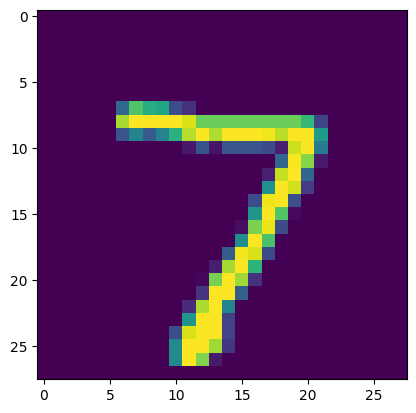

In [32]:
plt.imshow(X_test[0])

In [36]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([7])

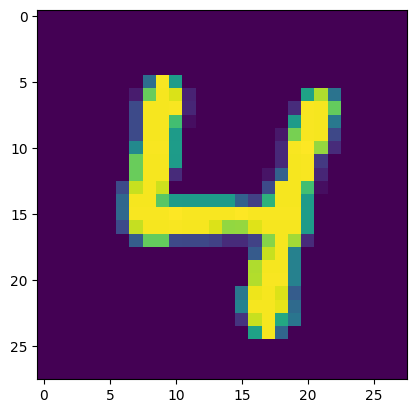

In [39]:
plt.imshow(X_test[56])

In [40]:
model.predict(X_test[56].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([4])